In [180]:
import pandas as pd
import numpy as np
from pathlib import Path
from src import data_processing, paths


input_data_dir = paths.PROCESSED_DATA_DIR
input_data_path = input_data_dir / 'BARTER_DEALS_CLEAN.parquet'
df = pd.read_parquet(input_data_path)

# Comments
- Check whether the image attractiveness (branding quality) is predictive of applications
    - Creators zijn visueel ingesteld
- Remove zero apps: there was a bug in the app where Live deals were not visible. Therefore, remove them. 
- Alignment with Creators/influencers 
- How easy it is to capture the product in an image
- Number of pictures

# General features

In [181]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['month'] = df['created_at'].dt.to_period('M')

# Data cleaning

In [182]:
import pandas as pd
from functools import wraps

# --- Logging Tool (Decorator) ---


def log_step(func):
    """
    A decorator that prints the shape of the dataframe before and after 
    a function execution, effectively tracking data loss.
    """
    @wraps(func)
    def wrapper(df, *args, **kwargs):
        start_len = len(df)
        result_df = func(df, *args, **kwargs)
        end_len = len(result_df)
        diff = start_len - end_len
        pct_lost = (diff / start_len * 100) if start_len > 0 else 0

        print(f"[{func.__name__:<25}] Start: {start_len:<6} | End: {end_len:<6} | Dropped: {diff:<5} ({pct_lost:.1f}%)")
        return result_df
    return wrapper

# --- Atomic Cleaning Steps ---

@log_step
def start_date(df, start_date):
    return df[df['month'] > start_date]

@log_step
def filter_incomplete_weeks(df):
    cutoff_date = df['created_at'].max() - pd.Timedelta(days=14)
    return df[df['created_at'] < cutoff_date].copy()


@log_step
def filter_low_n_categories(df, min_observations=50):
    counts = df['first_content_type'].value_counts()
    valid_categories = counts[counts >= min_observations].index
    return df[df['first_content_type'].isin(valid_categories)].copy()

@log_step
def filter_dead_high_volume_deals(df, floor=30):
    condition = (df['applicants_applications_count'] >
                 floor) & (df['apps_after_7_days'] == 0)
    return df[~condition].copy()


@log_step
def filter_archived(df):
    return df[df['status'] != 'archived'].copy()


@log_step
def filter_partners(df, partner_ids_to_remove):
    return df[~df['legacy_partner_id'].isin(partner_ids_to_remove)].copy()


@log_step
def filter_languages(df, languages_to_remove):
    return df[~df['deal_language'].isin(languages_to_remove)].copy()


@log_step
def filter_for_deal_value(df, min_deal_value, max_deal_value):
    if min_deal_value == 'skip':
        return df
    return df[(df.deal_value > min_deal_value) & (df.deal_value < max_deal_value)]


@log_step
def min_apps_after_seven_days(df, min_apps_after_7_days):
    # Sets a minimum for the KPI, with the idea of modelling the non-zero deals. Set to -1 to ignore
    return df[df['apps_after_7_days'] > min_apps_after_7_days].copy()

@log_step
def min_apps_total(df, min_apps):
    return df[df['applicants_applications_count'] > min_apps].copy()



@log_step
def filter_invalid_deals(df):
    """
    Removes deals that were structurally incapable of receiving applications.
    This avoids Truncation Bias by filtering on INPUTS (status), not OUTPUTS (apps).
    """

    # Date Check
    has_start_date = df['go_live_at'].notna()
    
    # Content Check (Optional but recommended based on your finding)
    has_images = df['images'].notna()

    # Combine
    valid_deals = has_start_date & has_images
    
    return df[valid_deals].copy()


@log_step
def max_follower_requirement(df, max_follower_requirement):
    return df[df['min_social_media_followers'] < max_follower_requirement]

@log_step
def log_transform_cols(df, cols):
    """
    Applies log1p transformation to specified columns.
    Creates new columns with 'log_' prefix to preserve original data.
    """
    # Create a copy to avoid SettingWithCopyWarning on slice
    df = df.copy()

    for col in cols:
        if col in df.columns:
            # log1p calculates log(1 + x), safe for 0 values
            df[f'log_{col}'] = np.log1p(df[col])
        else:
            print(
                f"⚠️ Warning: Column '{col}' not found, skipping log transform.")

    return df

# Note: Winsorizing is a transformation, not a filter, so it usually doesn't change row count.
# We can skip the @log_step here or create a different logger for transformations.


def apply_transformations(df):
    df = df.copy()
    # Apply winsorization logic here (assuming function exists)
    # df['apps_after_7_days_clean'] = ...

    df['social_requirement_type_id'] = df['social_requirement_type_id'].astype(
        int).astype(str)
    return df

# --- The Pipeline ---


def run_cleaning_pipeline(raw_df, config):
    print(f"{'STEP':<30} {'START':<6}   {'END':<6}   {'DROPPED':<5} {'% LOSS'}")
    print("-" * 75)

    clean_df = (
        raw_df
        .pipe(start_date, start_date=config['START_DATE'])
        .pipe(filter_incomplete_weeks)
        .pipe(filter_low_n_categories, min_observations=config["MIN_CATEGORY_OBSERVATIONS"])
        .pipe(filter_dead_high_volume_deals, floor=config["diff_total_apps_7_days_floor"])
        .pipe(filter_archived)
        .pipe(max_follower_requirement, max_follower_requirement=config['max_follower_requirement'])
        .pipe(min_apps_after_seven_days, min_apps_after_7_days=config['min_apps_after_7_days'])
        .pipe(min_apps_total, min_apps = config['MIN_APPS_TOTAL'])
        # .pipe(filter_invalid_deals)
        .pipe(filter_partners, partner_ids_to_remove=config["PARTNER_IDS_TO_REMOVE"])
        .pipe(filter_languages, languages_to_remove=config["DEAL_LANGUAGES_TO_REMOVE"])
        .pipe(filter_for_deal_value, min_deal_value=config["MIN_DEAL_VALUE"], max_deal_value=config["MAX_DEAL_VALUE"])
        .pipe(log_transform_cols, cols=config['LOG_TRANSFORM_COLS'])
    )

    # Apply non-filtering transformations at the end (usually these don't drop rows)
    # clean_df = apply_transformations(clean_df)

    return clean_df

In [183]:
# 1. Define your configuration dictionary
cleaning_config = {
    "START_DATE": "2025-05",
    "MIN_CATEGORY_OBSERVATIONS": 50,
    "PARTNER_IDS_TO_REMOVE": [85, 4],
    "DEAL_LANGUAGES_TO_REMOVE": ['de'],
    "diff_total_apps_7_days_floor": 10,
    'MIN_APPS_TOTAL': 0,
    'min_apps_after_7_days': -1,
    "MIN_DEAL_VALUE": 0,
    "MAX_DEAL_VALUE": 1000,
    "LOG_TRANSFORM_COLS": ['deal_value'],
    "max_follower_requirement": 25000
}


clean_df = run_cleaning_pipeline(df, cleaning_config)

STEP                           START    END      DROPPED % LOSS
---------------------------------------------------------------------------
[start_date               ] Start: 6472   | End: 3104   | Dropped: 3368  (52.0%)
[filter_incomplete_weeks  ] Start: 3104   | End: 2997   | Dropped: 107   (3.4%)
[filter_low_n_categories  ] Start: 2997   | End: 2681   | Dropped: 316   (10.5%)
[filter_dead_high_volume_deals] Start: 2681   | End: 2649   | Dropped: 32    (1.2%)
[filter_archived          ] Start: 2649   | End: 2621   | Dropped: 28    (1.1%)
[max_follower_requirement ] Start: 2621   | End: 2471   | Dropped: 150   (5.7%)
[min_apps_after_seven_days] Start: 2471   | End: 2471   | Dropped: 0     (0.0%)
[min_apps_total           ] Start: 2471   | End: 1923   | Dropped: 548   (22.2%)
[filter_partners          ] Start: 1923   | End: 1850   | Dropped: 73    (3.8%)
[filter_languages         ] Start: 1850   | End: 1575   | Dropped: 275   (14.9%)
[filter_for_deal_value    ] Start: 1575   | End: 632

In [184]:
def create_market_scope(row):
    # 1. Is it Multi-country?
    if row['nr_of_accepted_countries'] > 1:
        # Optional: You could split this further into "Intl_with_NL" and "Intl_no_NL"
        # if you think adding NL to an international bundle matters.
        return 'International'
    
    # 2. It is Single Country. Is it NL?
    if row['includes_NL'] == 1:
        return 'NL_Local'  # This is your dominant group (223 rows)
    
    # 3. It is Single Country, not NL
    return 'Other_Local'


def feature_engineering(ratings_df, GROUPS, CATS, CONTS, BINS, CLUSTER_COL, SCORE_VAR, TARGET):
    df = ratings_df.copy()

    # Log of applications
    df['log_apps'] = np.log1p(df['apps_after_7_days'])

    # Compute offset parameter
    monthly_means = df.groupby('month')[TARGET].transform('mean')
    df['log_offset'] = np.log(monthly_means + 0.01)

    # Market scope
    df.loc[:,'nr_of_accepted_countries'] = [len(x) for x in df['accepted_countries']]
    df.loc[:,'includes_NL'] = [['NLD'] in x for x in df.accepted_countries]
    df['market_scope'] = df.apply(create_market_scope, axis=1)
    # df.loc[:,'log_nr_of_accepted_countries'] = np.log1p(df.loc[:,'nr_of_accepted_countries'])


    # Description length
    df['log_desc_length'] = np.log1p(df['deal_text'].str.len())

    # Take mean of duplicate deal texts
    if 'dimension_name' in ratings_df.columns:
        CATS_dict = {x: 'first' for x in CATS + BINS + [CLUSTER_COL]}
        CONT_dict = {x: 'mean' for x in [
            TARGET] + CONTS + [SCORE_VAR] + ['log_offset']}
        agg_dicts = CONT_dict | CATS_dict

        df = df.groupby(['deal_text'] + ['dimension_name'] +
                        GROUPS).agg(agg_dicts).reset_index()

    return df

In [185]:
# 2. Define Variables (Move these to your config.yaml later!)
GROUPS = ['model_name', 'prompt_id']

###
TARGET = 'apps_after_7_days'
TARGET = 'log_apps'
# TARGET = 'apps_after_7_days_clean'
# TARGET = 'apps_after_7_days_OLD'
# TARGET = 'applicants_applications_count'

###
# Categorical variables
CATS = []
CATS = ['first_content_type']
CATS = ['first_content_type', 'market_scope']
CATS = ['first_content_type', 'includes_NL']
# CATS = ['first_content_type', 'market_scope', 'social_requirement_type_id']
# CATS = ['deal_type', 'social_requirement_type_id']
# CATS = ['social_requirement_type_id']
# CATS = ['first_content_type', 'social_requirement_type_id']
# CATS = ['social_requirement_type_id', 'deal_language']
# CATS = ['deal_type', 'first_content_type']
# CATS = ['deal_type', 'first_content_type', 'social_requirement_type_id']
# CATS = ['first_content_type', 'social_requirement_type_id']
# CATS = ['first_content_type', 'deal_language', 'deal_type', 'social_requirement_type_id']


CONTS = []
CONTS = ['log_deal_value', 'log_desc_length', 'nr_of_accepted_countries']

# CONTS = ['deal_value']


###
# Binary variables
BINS = []
# BINS = ['accepts_international']  # Already 0/1 or T/F

###
# LLM evaluation variable
SCORE_VAR = 'mean_rating'

###
# Column for Clustered standard errors
CLUSTER_COL = 'partner_id'


# Feature engineering
feature_config = {
    "GROUPS": GROUPS,
    "CONTS": CONTS,
    "CATS": CATS,
    "BINS": BINS,
    "CLUSTER_COL": CLUSTER_COL,
    "SCORE_VAR": SCORE_VAR,
    "TARGET": TARGET
}


model_df = feature_engineering(
    clean_df, GROUPS, CATS, CONTS, BINS, CLUSTER_COL, SCORE_VAR, TARGET)


# Models

In [186]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from typing import List, Optional

def build_base_predictor_matrix(
    df: pd.DataFrame,
    num_predictors: List[str],  # e.g., ['log_deal_value']
    bin_predictors: List[str],  # e.g., ['accepts_international']
    cat_predictors: List[str],  # e.g., ['first_content_type', 'social_requirement_type_id']
    drop_na: bool = True
) -> Optional[pd.DataFrame]:
    """
    Builds a clean design matrix (X) for OLS regression.
    
    Handles:
    - Numeric/Binary columns
    - One-hot encoding for Categoricals (with drop_first=True)
    - Constant term (Intercept)
    - Infinity/NaN checks
    - Rank deficiency check
    """
    
    # 1. Create a working copy to avoid SettingWithCopy warnings
    #    We only select the columns we need to prevent shape mismatch later
    needed_cols = num_predictors + bin_predictors + cat_predictors
    X = df[needed_cols].copy()

    # 2. Safety: Handle Infinite values (common with log transformations)
    #    Replace -inf/inf with NaN so they are caught in the next step
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 3. Safety: Drop NaNs
    if drop_na:
        original_len = len(X)
        X = X.dropna()
        dropped_count = original_len - len(X)
        if dropped_count > 0:
            print(f"ℹ️ Dropped {dropped_count} rows containing missing or infinite values.")
    
    if X.empty:
        print("❌ Error: DataFrame is empty after cleaning.")
        return None

    predictor_parts = []

    # 4. Process Numeric & Binary
    #    Ensure binary cols are actual integers (0/1)
    if num_predictors or bin_predictors:
        X_num = X[num_predictors + bin_predictors].copy()
        for col in bin_predictors:
            X_num[col] = X_num[col].astype(int)
        predictor_parts.append(X_num)

    # 5. Process Categorical (One-Hot Encoding)
    if cat_predictors:
        # Force to string first to ensure categories are treated as discrete
        X_cat_subset = X[cat_predictors].astype(str)
        
        # drop_first=True is CRITICAL for OLS to avoid the "Dummy Variable Trap"
        # (perfect multicollinearity between dummies and the intercept)
        X_dummies = pd.get_dummies(X_cat_subset, drop_first=True, dtype=int)
        predictor_parts.append(X_dummies)

    # 6. Combine and Add Constant
    if not predictor_parts:
        print("❌ Error: No predictors provided.")
        return None

    X_final = pd.concat(predictor_parts, axis=1)
    
    # Add Intercept (Beta_0)
    X_final = sm.add_constant(X_final)

    # 7. Rank Check (Multicollinearity)
    #    If rank < number of columns, the matrix is singular (math breaks)
    if np.linalg.matrix_rank(X_final.values) < X_final.shape[1]:
        print("⚠️ Warning: Design matrix is rank-deficient. You have perfect multicollinearity.")
        print("   Check if one variable is a linear combination of others (e.g., 'is_male' vs 'is_female').")
    
    return X_final

## OLS

In [187]:
# model_df = model_df[model_df['market_scope'] != 'Other_Local']


X = build_base_predictor_matrix(
    df= model_df,
    num_predictors=CONTS,  # e.g., ['log_deal_value']
    bin_predictors=BINS,  # e.g., ['accepts_international']
    cat_predictors=CATS,  # e.g., ['first_content_type', 'social_requirement_type_id']
    drop_na=True
)

y = model_df.loc[X.index, TARGET]

model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': model_df.loc[X.index, 'partner_id']})

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_apps   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     10.31
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           2.01e-18
Time:                        16:54:11   Log-Likelihood:                -863.34
No. Observations:                 632   AIC:                             1755.
Df Residuals:                     618   BIC:                             1817.
Df Model:                          13                                         
Covariance Type:              cluster                                         
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              1.1009      0.403      2.730      0.006       0.311       1.891
log_deal_value                     0.2587      0.057      4.535      0.000       0.147       0.371
log_desc_length                   -0.1653      0.056     -2.958      0.003      -0.275      -0.056
nr_of_accepted_countries           0.0513      0.019      2.653      0.008       0.013       0.089
first_content_type_Beauty          0.5762      0.158      3.649      0.000       0.267       0.886
first_content_type_Cooking         0.3919      0.186      2.109      0.035       0.028       0.756
first_content_type_Experiences    -0.0604      0.170     -0.356      0.722      -0.393       0.273
first_content_type_Fashion         0.4721      0.243      1.946      0.052      -0.003       0.947
first_content_type_Food            0.1924      0.224      0.858      0.391      -0.247       0.632
first_content_type_Lifestyle       0.4399      0.310      1.418      0.156      -0.168       1.048
first_content_type_Luxury          0.4929      0.150      3.295      0.001       0.200       0.786
first_content_type_Tech            0.3452      0.390      0.884      0.376      -0.420       1.110
first_content_type_UGC             0.2828      0.170      1.659      0.097      -0.051       0.617
includes_NL_True                   0.8698      0.114      7.651      0.000       0.647       1.093
==============================================================================
Omnibus:                        1.389   Durbin-Watson:                   1.909
Prob(Omnibus):                  0.499   Jarque-Bera (JB):                1.268
Skew:                           0.004   Prob(JB):                        0.530
Kurtosis:                       3.219   Cond. No.                         80.8
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

### Diagnostics

- Check if assumptions are violated

c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


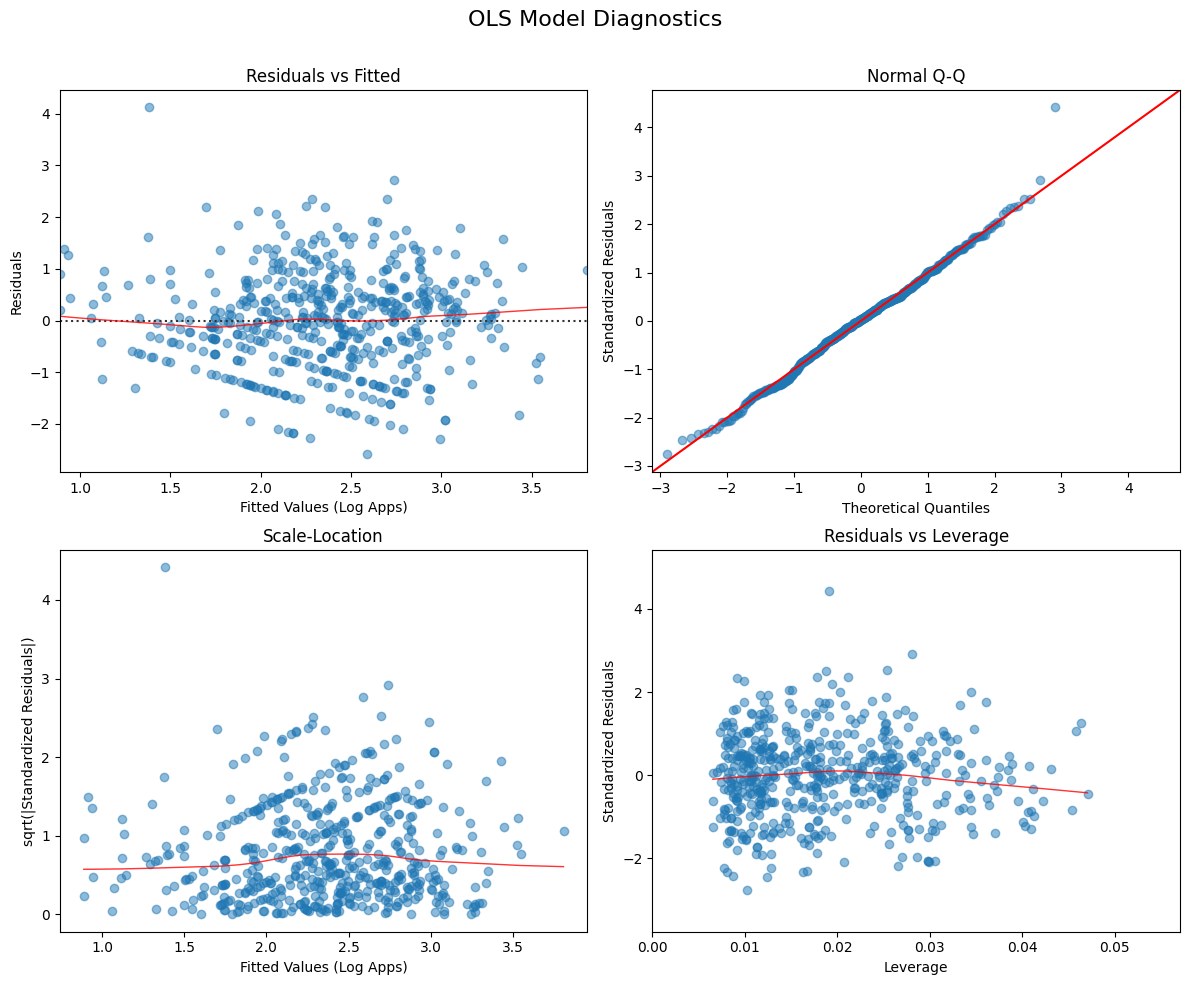

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot
import numpy as np

def run_diagnostics(results):
    """
    Generates industry-standard diagnostic plots for OLS regression.
    Args:
        results: The fitted statsmodels OLS result object.
    """
    
    # 1. Basic Data Prep
    model_fitted_y = results.fittedvalues
    model_residuals = results.resid
    model_norm_residuals = results.get_influence().resid_studentized_internal
    model_abs_resid = np.abs(model_norm_residuals)
    model_leverage = results.get_influence().hat_matrix_diag
    model_cooks = results.get_influence().cooks_distance[0]

    # Set up the figure structure
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle('OLS Model Diagnostics', fontsize=16)

    # --- Plot 1: Residuals vs Fitted ---
    # Checks for: Non-linearity and Heteroskedasticity
    ax1 = fig.add_subplot(2, 2, 1)
    sns.residplot(x=model_fitted_y, y=model_residuals, 
                  lowess=True, 
                  scatter_kws={'alpha': 0.5}, 
                  line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax1)
    ax1.set_title('Residuals vs Fitted')
    ax1.set_xlabel('Fitted Values (Log Apps)')
    ax1.set_ylabel('Residuals')

    # --- Plot 2: Normal Q-Q ---
    # Checks for: Normality of residuals
    ax2 = fig.add_subplot(2, 2, 2)
    QQ = ProbPlot(model_norm_residuals)
    QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1, ax=ax2)
    ax2.set_title('Normal Q-Q')
    ax2.set_xlabel('Theoretical Quantiles')
    ax2.set_ylabel('Standardized Residuals')

    # --- Plot 3: Scale-Location (Spread-Location) ---
    # Checks for: Homoscedasticity (Constant Variance)
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.scatter(model_fitted_y, model_abs_resid, alpha=0.5)
    sns.regplot(x=model_fitted_y, y=model_abs_resid, 
                scatter=False, 
                ci=False, 
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax3)
    ax3.set_title('Scale-Location')
    ax3.set_xlabel('Fitted Values (Log Apps)')
    ax3.set_ylabel('sqrt(|Standardized Residuals|)')

    # --- Plot 4: Residuals vs Leverage ---
    # Checks for: Influential Outliers (Cook's Distance)
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.scatter(model_leverage, model_norm_residuals, alpha=0.5)
    sns.regplot(x=model_leverage, y=model_norm_residuals, 
                scatter=False, 
                ci=False, 
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax4)
    
    # Add Cook's distance lines (Thresholds)
    # Ideally, points should be inside the dashed lines
    ax4.set_xlim(0, max(model_leverage) + 0.01)
    ax4.set_ylim(min(model_norm_residuals)-1, max(model_norm_residuals)+1)
    ax4.set_title('Residuals vs Leverage')
    ax4.set_xlabel('Leverage')
    ax4.set_ylabel('Standardized Residuals')
    
    # Optional: Draw Cook's distance lines for 0.5 and 1.0
    # (High influence thresholds)
    p = len(results.params) # number of parameters
    def graph(formula, x_range, label=None):
        x = x_range
        y = formula(x)
        plt.plot(x, y, label=label, lw=1, ls='--', color='gray')

    # Cook's distance = 0.5 line
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x), 
          np.linspace(0.001, max(model_leverage), 50), 'Cook\'s Dist=0.5')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Run it on your results
run_diagnostics(model)

- Check for which deals the predictions are good and for which they are bad

In [191]:
def inspect_model_errors(model_results, df, n=5):
    """
    Appends predictions and errors to the dataframe and displays extreme cases.
    """
    # 1. Add Predictions and Residuals to a copy of the data
    # Ensure indices align (statsmodels drops NaNs, so use the model's index)
    analysis_df = df.loc[model_results.fittedvalues.index].copy()
    
    # Get fitted values (Log Scale)
    analysis_df['log_predicted'] = model_results.fittedvalues
    analysis_df['log_actual'] = model_results.model.endog
    
    # Transform back to Real Count Scale (Exp - 1) for readability
    analysis_df['pred_apps'] = np.expm1(analysis_df['log_predicted']).round(1)
    analysis_df['actual_apps'] = np.expm1(analysis_df['log_actual']).astype(int)
    
    # Calculate Residual (Positive = Overperformed, Negative = Underperformed)
    analysis_df['error'] = analysis_df['actual_apps'] - analysis_df['pred_apps']
    
    # 2. Display the "Overperformers" (Model predicted Low, Actual was High)
    print(f"\n--- TOP {n} OVERPERFORMERS (Unexplained Success) ---")
    cols_to_show = ['deal_title', 'deal_text', 'deal_value', 'actual_apps', 'pred_apps', 'error']
    overperformers = analysis_df.sort_values(by='error', ascending=False).head(n)
    display(overperformers[cols_to_show])
    
    # 3. Display the "Underperformers" (Model predicted High, Actual was Low)
    print(f"\n--- TOP {n} UNDERPERFORMERS (Unexplained Failure) ---")
    underperformers = analysis_df.sort_values(by='error', ascending=True).head(n)
    display(underperformers[cols_to_show])
    
    return analysis_df

# Run the function
error_df = inspect_model_errors(model, model_df, n=40)


--- TOP 40 OVERPERFORMERS (Unexplained Success) ---


,deal_title,deal_text,deal_value,actual_apps,pred_apps,error
2314,TUI Early Booking Travel Video | €150,"<p>Maak&nbsp;een&nbsp;warme,&nbsp;dynamische&n...",150.0,244,3.0,241.0
2315,Otrium Shopping Haul | €200 Voucher (NL),<p>It’s&nbsp;time&nbsp;to&nbsp;shop&nbsp;smart...,200.0,231,15.4,215.6
1706,Kledingset unboxing + passen,<p>Wij&nbsp;van&nbsp;Godlystore&nbsp;zoeken&nb...,99.0,154,14.2,139.8
5134,€150 Emira Jewelry Credit ✨,You’ll receive a €150 e-voucher to pick your f...,150.0,132,20.5,111.5
2246,Make content with our make-up products,Select 3 make-up products for free on our webs...,80.0,135,23.6,111.4
6074,STFU MiniMemory - Make memories with this mini...,The STFU MiniMemory is a mini camera that blen...,50.0,102,9.1,92.9
5783,Safecourt slowjuicer,Je ontvangt kosteloos een Safecourt slowjuicer...,150.0,94,9.5,84.5
5365,Gratis Vlekkenreiniger + verdien goed met je v...,De Kymo Vlekkenreiniger Ultra is een klein en ...,150.0,94,13.0,81.0
6176,Luxury Aluminium Suitcase,AluPacific has Aluminium Luxury Suitcases witc...,500.0,120,39.5,80.5
5375,Gratis Stoomreiniger + verdien goed met je vid...,De Kymo 9-in-1 Stoomreiniger is een veelzijdig...,150.0,92,12.7,79.3



--- TOP 40 UNDERPERFORMERS (Unexplained Failure) ---


,deal_title,deal_text,deal_value,actual_apps,pred_apps,error
5999,Try our new file sharing service for Creators,You will get a 12 month PRO account for free.,500.0,5,43.9,-38.9
5110,"€389,- Premium leather bag deal (duplicate)","Evan Red creates high-end, handcrafted leather...",389.0,3,29.7,-26.7
5726,Online Lip Blush Course or Luxury Cosmetics,"I’m Kate Tiu – award-winning PMU artist, inter...",500.0,10,33.4,-23.4
6222,Plus-size creators wanted: XL–5XL menswear collab,We’re offering one piece of Mr Main Man menswe...,180.0,2,20.1,-18.1
6225,2XL–5XL men’s style collab—let’s team up!,We’re offering two pieces of Mr Main Man mensw...,180.0,2,20.1,-18.1
5628,Style Your Wrist: Men’s Watch + Accessories (€...,You receive a €100 voucher to pick any men’s w...,100.0,1,18.1,-17.1
193,huidverjonging peeling,huidverjonging peeling | Een fruitzuren peelin...,129.0,5,21.5,-16.5
5537,"Try SQUID, the textile window film",We offer SQUID (textile window film) for your ...,350.0,16,32.4,-16.4
1560,PMU Wenkbrauw,gratis behandeling permanente make up wenkbrauwen,299.0,14,29.8,-15.8
5456,Luxe Tuinverlichting (t.w.v. €200),Je ontvangt één of meerdere armaturen van Ligh...,200.0,3,17.9,-14.9


In [192]:
error_df.applicants_applications_count - error_df.apps_after_7_days

44       30
46       16
91        2
145     201
147      39
       ... 
7242      2
7244     14
7254      2
7255      0
7256      0
Length: 632, dtype: int64

In [ ]:
error_df['diff_total_apps_seven_days'] = error_df.applicants_applications_count - error_df.apps_after_7_days
error_df


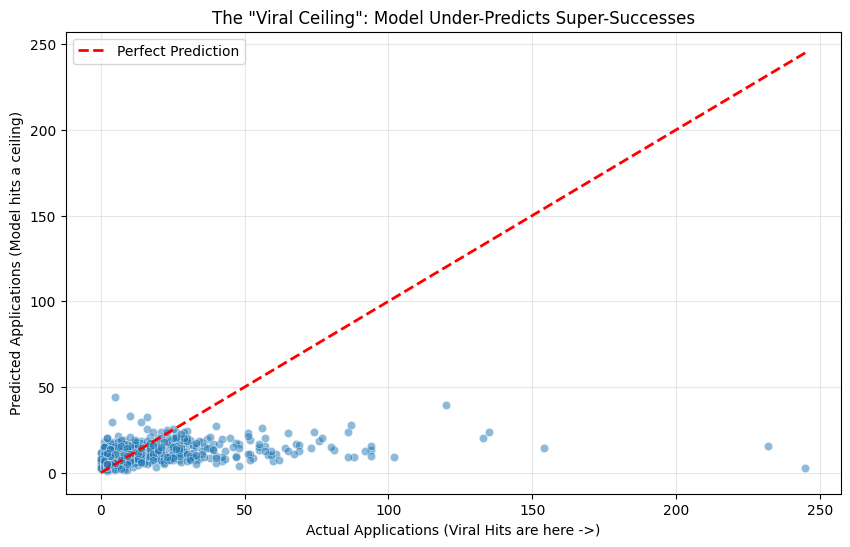

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_prediction_ceiling(model_results, df):
    # 1. Get data
    # Create a copy to avoid SettingWithCopyWarning
    plot_data = df.loc[model_results.fittedvalues.index].copy()
    plot_data['log_predicted'] = model_results.fittedvalues
    plot_data['log_actual'] = model_results.model.endog
    
    # 2. Convert back to counts for the plot (easier to see the 44 vs 244 gap)
    plot_data['pred_count'] = np.expm1(plot_data['log_predicted'])
    plot_data['actual_count'] = np.expm1(plot_data['log_actual'])
    
    # 3. Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='actual_count', y='pred_count', data=plot_data, alpha=0.5)
    
    # Add the "Perfect Prediction" line
    max_val = max(plot_data['actual_count'].max(), plot_data['pred_count'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    plt.title('The "Viral Ceiling": Model Under-Predicts Super-Successes')
    plt.xlabel('Actual Applications (Viral Hits are here ->)')
    plt.ylabel('Predicted Applications (Model hits a ceiling)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_prediction_ceiling(model, model_df)

In [196]:
# Check the partners of the biggest underpredictions
misses = error_df.sort_values(by='error', ascending=False).head(20)
misses[['deal_title', 'deal_text', 'actual_apps', 'pred_apps', 'error']]

,deal_title,deal_text,actual_apps,pred_apps,error
2314,TUI Early Booking Travel Video | €150,"<p>Maak&nbsp;een&nbsp;warme,&nbsp;dynamische&n...",244,3.0,241.0
2315,Otrium Shopping Haul | €200 Voucher (NL),<p>It’s&nbsp;time&nbsp;to&nbsp;shop&nbsp;smart...,231,15.4,215.6
1706,Kledingset unboxing + passen,<p>Wij&nbsp;van&nbsp;Godlystore&nbsp;zoeken&nb...,154,14.2,139.8
5134,€150 Emira Jewelry Credit ✨,You’ll receive a €150 e-voucher to pick your f...,132,20.5,111.5
2246,Make content with our make-up products,Select 3 make-up products for free on our webs...,135,23.6,111.4
6074,STFU MiniMemory - Make memories with this mini...,The STFU MiniMemory is a mini camera that blen...,102,9.1,92.9
5783,Safecourt slowjuicer,Je ontvangt kosteloos een Safecourt slowjuicer...,94,9.5,84.5
5365,Gratis Vlekkenreiniger + verdien goed met je v...,De Kymo Vlekkenreiniger Ultra is een klein en ...,94,13.0,81.0
6176,Luxury Aluminium Suitcase,AluPacific has Aluminium Luxury Suitcases witc...,120,39.5,80.5
5375,Gratis Stoomreiniger + verdien goed met je vid...,De Kymo 9-in-1 Stoomreiniger is een veelzijdig...,92,12.7,79.3


-------

# EDA

## Full DF

In [ ]:
df

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,min_social_media_followers,pending_applications_count,planned_applications_count,rejected_applications_count,total_company_locations,upcoming_applications_count,first_content_type,apps_after_7_days,deal_language,days_since_start
0,2025-02-21 09:47:19.029007,2026-01-12 07:39:16.765647,NaT,019689e1-dadd-00c8-5101-e0d07384f6dd,1170.0,Heerlijke steak bij Coco's Outback in Amsterdam,Je bent welkom om nog een persoon mee te nemen...,- Vooraf spreken we een datum en tijd af. Zond...,,draft,...,5000,15,5,24,1,5,Food,17,nl,532
1,2025-03-26 08:56:24.776549,2026-01-12 07:39:16.908385,NaT,019689e1-de33-00c8-297c-7a4241d57de4,745.0,Outdoor chalkboard and markers to celebrate go...,Celebrate good times with our rectangle chalkb...,-1 reel\n-1 static post\n-Share with us for ou...,,inactive,...,2500,7,2,0,1,2,UGC,2,en,565
2,2025-02-21 12:14:54.016826,2026-01-12 07:39:16.957884,NaT,019689e1-e3b3-00c8-60a3-6ff40abe4535,1081.0,Bite & Bowling,Bite & Bowling! 🎳🍽️\n\nBij Lucky’s Bowling lan...,We zoeken spontane en gezellige dames en heren...,,draft,...,5000,0,1,0,1,1,Activities,2,nl,533
3,2025-03-26 10:58:10.050719,2026-01-12 07:39:17.032326,NaT,019689e1-e796-00c8-dfeb-bc61800dd2d8,1156.0,Deze fles moet jij hebben!!,"Meta barst van de standaard productreviews, ma...",•\tHet filmpje is minimaal 15 seconden en maxi...,,live,...,5000,1,3,31,1,3,Activities,3,nl,566
4,2025-03-26 11:14:23.339791,2026-01-12 07:39:17.071050,NaT,019689e1-e94a-00c8-d860-fccce5580ced,1156.0,Review onze 750ml Saywhat Bottle,Onze 750ml Saywhat Bottle is de perfecte fles ...,Requirements:\n•\tHet filmpje is minimaal 15 s...,,live,...,5000,0,2,13,1,2,Activities,0,nl,566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7268,2026-01-25 16:22:15.938891,2026-01-31 23:03:59.373750,NaT,019bf5f6-9282-00c8-a321-d43e3e00e578,NaN,Aantrekkelijke Aanbieding voor UGC Creators🔥,<p>Je&nbsp;ontvangt&nbsp;volledige&nbsp;premiu...,<p>Wat&nbsp;we&nbsp;zoeken</p><ul><li>Creators...,"#YourMotio,#persoonlijkeontwikkeling,#mindset,...",finished,...,1500,0,3,0,0,3,Experiences,3,nl,871
7269,2026-01-25 16:31:50.902867,2026-01-31 23:04:00.377427,NaT,019bf5ff-5876-00c8-35a6-e5a7dcb5369f,NaN,Maandelijks inkomen + gratis toegang tot YourM...,<p>Samenwerken&nbsp;met&nbsp;YourMotio</p><p>Y...,<p>Wat&nbsp;we&nbsp;van&nbsp;jou&nbsp;vragen</...,"#YourMotio,#persoonlijkeontwikkeling,#mindset,...",finished,...,1500,0,1,0,0,1,Experiences,1,nl,871
7270,2026-01-16 15:47:39.999471,2026-02-05 04:00:02.372342,NaT,019bc77d-a95f-00c8-e8c0-6cbe4e05db15,NaN,Design Wanduhren mit Charakter,<p>Von&nbsp;<strong>Pattern&nbsp;Clock</strong...,"<p>Hallo,</p><p>ich&nbsp;baue&nbsp;aktuell&nbs...","#Design,#Interior,#ModernLiving,#Wanduhr",draft,...,1500,6,0,0,0,0,UGC,5,de,862
7272,2025-09-15 09:16:48.051838,2026-02-05 04:00:05.652332,NaT,01994ca9-9c33-00c8-4d1d-dc713a3d0713,2130.0,Erhalten Sie 75 € Shop-Guthaben! 💪,"Wir von Bandagenspezialist.de glauben, dass je...",Im Austausch für den Gutschein bitten wir Sie ...,,draft,...,5000,7,0,0,0,0,Activities,2,de,738


In [22]:
print(f"Proportion of deals before 2025-05: {(df['month'] < '2025-05').sum() / len(df)}")

Proportion of deals before 2025-05: 0.45565512978986406


In [37]:
model_df['updated_minus_created'] = model_df.updated_at - model_df.created_at

In [30]:
df['min_social_media_followers'].value_counts()

min_social_media_followers
5000     2198
2500     1942
1500     1164
10000     780
25000     243
50000     113
0          32
Name: count, dtype: int64

In [52]:
clean_df.groupby(['min_social_media_followers'])[['apps_after_7_days', 'deal_value']].corr().reset_index()

,min_social_media_followers,level_1,apps_after_7_days,deal_value
0,1500,apps_after_7_days,1.000000,0.129289
1,1500,deal_value,0.129289,1.000000
2,2500,apps_after_7_days,1.000000,0.181210
3,2500,deal_value,0.181210,1.000000
4,5000,apps_after_7_days,1.000000,0.044000
5,5000,deal_value,0.044000,1.000000
6,10000,apps_after_7_days,1.000000,0.280992
7,10000,deal_value,0.280992,1.000000


In [77]:
clean_df.total_company_locations.value_counts()

total_company_locations
0    449
1     74
2      7
3      2
7      1
9      1
4      1
6      1
Name: count, dtype: int64

In [43]:
clean_df.groupby('min_social_media_followers')['deal_value'].describe()

,count,mean,std,min,25%,50%,75%,max
min_social_media_followers,,,,,,,,
1500,201.0,82.024876,92.040667,1.0,30.0,60.0,100.00,999.0
2500,142.0,109.816901,90.041489,13.0,60.0,100.0,133.75,750.0
5000,131.0,127.961832,97.418479,15.0,50.0,100.0,179.00,599.0
10000,62.0,151.709677,121.105615,20.0,70.5,100.0,200.00,500.0


In [33]:
pd.crosstab(df['month'], df['min_social_media_followers'] > 40000)

min_social_media_followers,False,True
month,,
2023-09,36,8
2023-10,102,2
2023-11,64,2
2023-12,34,4
2024-01,50,3
2024-02,83,2
2024-03,130,4
2024-04,78,1
2024-05,109,2


In [85]:
pd.crosstab(df['month'], df['deal_value'] > 0)

deal_value,False,True
month,,
2023-09,44,0
2023-10,104,0
2023-11,66,0
2023-12,38,0
2024-01,53,0
2024-02,85,0
2024-03,134,0
2024-04,79,0
2024-05,108,3


In [23]:
df['month'].value_counts().sort_index()

month
2023-09     44
2023-10    104
2023-11     66
2023-12     38
2024-01     53
2024-02     85
2024-03    134
2024-04     79
2024-05    111
2024-06     78
2024-07    117
2024-08     60
2024-09    129
2024-10    205
2024-11    212
2024-12    191
2025-01    233
2025-02    330
2025-03    342
2025-04    338
2025-05    419
2025-06    423
2025-07    438
2025-08    293
2025-09    447
2025-10    420
2025-11    428
2025-12    301
2026-01    353
2026-02      1
Freq: M, Name: count, dtype: int64

In [68]:
df.groupby('month')['apps_after_7_days'].sum()

month
2023-09     296
2023-10     495
2023-11     291
2023-12     434
2024-01     574
2024-02     692
2024-03    1047
2024-04     497
2024-05     533
2024-06     435
2024-07     545
2024-08     362
2024-09     889
2024-10    1714
2024-11    2113
2024-12    1665
2025-01    2768
2025-02    3673
2025-03    4105
2025-04    3922
2025-05    3448
2025-06    4074
2025-07    4981
2025-08    3531
2025-09    4607
2025-10    7680
2025-11    6489
2025-12    4348
2026-01    3667
2026-02       1
Freq: M, Name: apps_after_7_days, dtype: int64

## Clean df

In [126]:
clean_df

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,planned_applications_count,rejected_applications_count,total_company_locations,upcoming_applications_count,first_content_type,apps_after_7_days,deal_language,days_since_start,month,log_deal_value
9,2025-12-30 09:24:39.120652,2026-01-12 07:39:41.019023,NaT,019b6e92-e450-00c8-ba72-bd31dc315002,3732.0,All Day Bites & Cocktails at Down Under,We nodigen je uit bij Down Under om onze nieuw...,In ruil vragen we om content die de ervaring b...,#downundernieuwegein,draft,...,0,0,1,0,UGC,0,nl,844,2025-12,3.931826
44,2025-07-31 08:49:42.211582,2026-01-12 07:39:40.970409,NaT,01985fac-4543-00c8-bec7-39daedc6ec92,1695.0,Tapasbar Plan B - Vega(n) diner voor 2 personen!,Bij Plan B hebben wij een groot aanbod aan veg...,Wij verwachten een video die gepost wordt op T...,"#tapas,#tapasbreda,#vega,#vegan,#breda,#foodbr...",live,...,3,1,1,3,Experiences,8,nl,692,2025-07,4.709530
46,2025-07-31 09:01:47.423425,2026-01-12 07:39:41.014016,NaT,01985fb7-561f-00c8-9275-2a7e0744a116,1695.0,5L Sangria met 5 vrienden!,Bij Tapasbar Plan B serveren wij een heerlijke...,Een foto of video van de sangria op je eigen I...,"#sangria,#tapas,#breda,#tapasbreda,#sangriabre...",live,...,0,0,1,0,Food,9,nl,692,2025-07,4.709530
91,2025-09-09 13:54:30.557941,2026-01-12 07:39:17.699821,NaT,01992ec1-b41d-00c8-a494-e382d81ba7f4,840.0,Microdermabrasie facial (goud) 60 min,oppervlaktereiniging - dieptereiniging met ski...,Bruikbare content voor onze eigen kanalen verz...,"#Gorinchem,#CleyoGorinchem,#cleyoskinexperts,#...",finished,...,4,2,1,4,Beauty,10,nl,733,2025-09,4.653960
145,2025-09-11 07:53:52.285573,2026-01-13 10:00:30.108921,NaT,019937c4-3f9d-00c8-6a9b-a127425b823f,969.0,F1 Experience incl. borrelplank & drankjes,Ben jij influencer en wil je jouw volgers late...,Suggestions & requirements:\n\nContent moet mi...,#racesquare,live,...,11,13,7,11,Activities,60,nl,734,2025-09,4.605170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7242,2025-08-13 18:46:10.999031,2026-02-01 04:00:03.073606,NaT,0198a4c1-0936-00c8-915a-55912c9fcd8d,977.0,Panterprint bikini,Ben jij klaar om de zomer stijlvol in te luide...,– 1x Instagram Reel video waarin je de bikini...,#emiliecollection,draft,...,0,4,0,0,Fashion,2,nl,706,2025-08,3.931826
7244,2025-09-22 13:41:49.968953,2026-01-31 23:03:50.592176,NaT,019971a8-c510-00c8-f19b-d8b34c3cf589,2530.0,Test de ultieme slaapoordop en deel je ervaring,Dit najaar lanceren we Silent Sleep: een nieuw...,In ruil voor op maat gemaakte gehoorbeschermin...,"#Pluggerz,#SilentSleep",finished,...,4,4,0,4,Beauty,18,nl,746,2025-09,5.017280
7254,2026-01-06 19:38:22.031803,2026-01-31 23:03:57.681625,NaT,019b94d1-47cf-00c8-9903-09fc53dfef3c,3008.0,4 Free Kids Books + Earn Cash Per Sale 📚,<p>Calling&nbsp;all&nbsp;family&nbsp;&amp;&nbs...,<p>What&nbsp;we&nbsp;need&nbsp;from&nbsp;you:&...,"#MomTok,#KidsBooks,#MomLife,#KidsReading,#Pare...",finished,...,5,0,0,5,Experiences,7,en,852,2026-01,5.017280
7255,2026-01-14 14:35:03.139577,2026-01-31 23:03:58.277275,NaT,019bbcee-7663-00c8-dc81-a59920160cfb,NaN,Boekevent Meer dan konijneneten,<p>Voor&nbsp;de&nbsp;lancering&nbsp;van&nbsp;m...,<p>🤍&nbsp;Wat&nbsp;ik&nbsp;vraag&nbsp;in&nbsp;...,"#darmgezondheid,#glutenvrij,#lowcarb,#meerdank...",finished,...,2,1,0,2,Activities,7,nl,860,2026-01,4.615121


In [138]:
has_start_date = df['go_live_at'].notna()

In [142]:
(df['images'] != '[]')

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [141]:
df['images'].notna()

0       True
1       True
2       True
3       True
4       True
        ... 
7268    True
7269    True
7270    True
7272    True
7273    True
Name: images, Length: 6472, dtype: bool

In [128]:
clean_df_zero_apps = clean_df[clean_df.applicants_applications_count == 0]
clean_df_zero_apps

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,planned_applications_count,rejected_applications_count,total_company_locations,upcoming_applications_count,first_content_type,apps_after_7_days,deal_language,days_since_start,month,log_deal_value
9,2025-12-30 09:24:39.120652,2026-01-12 07:39:41.019023,NaT,019b6e92-e450-00c8-ba72-bd31dc315002,3732.0,All Day Bites & Cocktails at Down Under,We nodigen je uit bij Down Under om onze nieuw...,In ruil vragen we om content die de ervaring b...,#downundernieuwegein,draft,...,0,0,1,0,UGC,0,nl,844,2025-12,3.931826
148,2026-01-15 07:44:26.839016,2026-01-15 07:44:26.839016,NaT,019bc09c-e6d6-00c8-3d56-efbda8bbf53a,NaN,Pijnvrij bewegen met de Daili Movement,"<p><strong style=""background-color: rgb(252, 2...",<p>Instagram&nbsp;reels&nbsp;voor&nbsp;META&nb...,"#livethedifference,#dailipharma,#dailimovement...",draft,...,0,0,0,0,Activities,0,nl,860,2026-01,4.330733
166,2025-09-11 08:48:26.809985,2026-01-12 07:39:18.304553,NaT,019937f6-36b9-00c8-4257-b1d8f39d3962,2449.0,Gratis Personal Training bij Staetsgeheim (€95),Ontvang een gratis personal training sessie t....,– 1x Reel of TikTok van minimaal 30 seconden w...,#staetsgeheim,draft,...,0,0,1,0,Activities,0,nl,734,2025-09,4.564348
170,2025-09-11 09:43:04.319889,2026-01-12 07:39:18.466273,NaT,01993828-397f-00c8-569c-56732ae0588c,2453.0,Holiday on Ice – 4 Tickets naar keuze (€140),Je ontvangt 4 tickets voor de spectaculaire ni...,– 1x Reel of TikTok vóór het event waarin je d...,#holidayonice,draft,...,0,0,1,0,Experiences,0,nl,734,2025-09,4.948760
214,2025-09-16 09:06:01.256789,2026-01-12 07:39:18.888358,NaT,019951c6-19a8-00c8-7883-5061d10bb250,2430.0,Healthy Feast at Avatars (€50) 🥗⚡️,You’ll receive €50 in-store credit at Avatars ...,– 1× reel or TikTok (≥ 30 sec) filmed on locat...,"#Avatars,#HealthyFastCasual,#BuildYourBowl,#Ea...",draft,...,0,0,1,0,UGC,0,en,739,2025-09,3.931826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7224,2026-01-21 12:40:53.856660,2026-01-21 12:40:54.031874,NaT,019be092-7760-00c8-b3c6-d671b5f6ce17,NaN,Burger 'n Shake - 2x menu met loaded Fries & S...,<p>Bij&nbsp;<strong>Burger&nbsp;’n&nbsp;Shake<...,<p>📹&nbsp;<strong>1&nbsp;TikTok&nbsp;video</st...,#burgernshake,live,...,0,0,1,0,Activities,0,nl,867,2026-01,4.025352
7225,2026-01-21 12:43:31.402820,2026-01-21 13:57:55.625808,NaT,019be094-deca-00c8-2b27-55855d0c8e85,NaN,Burger 'n shake Leiden - 2x Menu met shake & f...,<p>Bij&nbsp;Burger&nbsp;’n&nbsp;Shake&nbsp;wer...,<p>📹&nbsp;1&nbsp;TikTok&nbsp;video&nbsp;</p><p...,#burgernshake,live,...,0,0,1,0,Activities,0,nl,867,2026-01,4.025352
7226,2026-01-21 12:43:52.298852,2026-01-21 13:56:41.808031,NaT,019be095-306a-00c8-a90b-ac9d47ab2178,NaN,Burger 'n shake Osdorp - 2x Menu met shake & f...,<p>Bij&nbsp;Burger&nbsp;’n&nbsp;Shake&nbsp;wer...,<p>📹&nbsp;1&nbsp;TikTok&nbsp;video&nbsp;</p><p...,#burgernshake,live,...,0,0,1,0,Activities,0,nl,867,2026-01,4.025352
7228,2026-01-21 13:46:10.497221,2026-01-26 09:54:51.283059,NaT,019be0ce-3ac1-00c8-947c-104f3bf0e318,NaN,1 maand gratis trainen bij I-Fitness 💪,<p>Je&nbsp;ontvangt&nbsp;1&nbsp;maand&nbsp;gra...,<p>–&nbsp;1×&nbsp;feed-video&nbsp;(≥&nbsp;30&n...,"#IFitness,#GymLife,#WorkoutMotivation,#Fitness...",draft,...,0,0,5,0,Luxury,0,nl,867,2026-01,4.094345


## Visualise over time

In [124]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Ensure datetime format
model_df['created_at'] = pd.to_datetime(model_df['created_at'])

# 2. Extract a numeric 'Time' feature for correlation (e.g., Days since start)
# We subtract the minimum date to get a "Day 0", "Day 1"... counter
# start_date = model_df['created_at'].min()
# og_df['days_since_start'] = (og_df['created_at'] - start_date).dt.days


def visualise_var_over_time(input_df, y_variable='apps_after_7_days', agg_type='sum'):

    # 3. Visualization: Two Views

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # View A: Raw Scatter (The Noise)
    # We sample 2000 points if the dataset is huge to prevent overplotting
    plot_data = input_df.sample(n=min(2000, len(input_df)), random_state=42)
    sns.scatterplot(
        data=plot_data,
        x='created_at',
        y='apps_after_7_days',
        alpha=0.3,
        ax=axes[0]
    )
    axes[0].set_title("Raw Data: Applications over Time")
    axes[0].set_ylabel("Apps after 7 Days")

    # View B: Monthly Trend (The Signal)
    # Resample by Month to see if the AVERAGE deal is getting more apps
    monthly_trend = input_df.set_index('created_at').resample('M')[
        y_variable].agg([agg_type, 'count'])
    sns.lineplot(data=monthly_trend, x=monthly_trend.index,
                 y=agg_type, ax=axes[1], color='red', linewidth=2)
    axes[1].set_title(
        f"Platform Trend: {agg_type} Applications per Deal (Monthly)")
    axes[1].set_ylabel(f"{agg_type} Apps per Deal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # 4. Statistical Check
    # Correlation between Time and Applications
    corr = input_df[['days_since_start', 'apps_after_7_days']].corr().iloc[0, 1]
    print(f"Correlation between Time and Application Count: {corr:.4f}")

    # Check for "Deal Volume" dilution
    # (Sometimes apps per deal DROP if deal volume grows faster than user base)
    volume_corr = monthly_trend[agg_type].corr(monthly_trend['count'])
    print(
        f"Correlation between Monthly Deal Volume and {agg_type} of {y_variable}: {volume_corr:.4f}")

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_11944\1060133430.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = input_df.set_index('created_at').resample('M')[


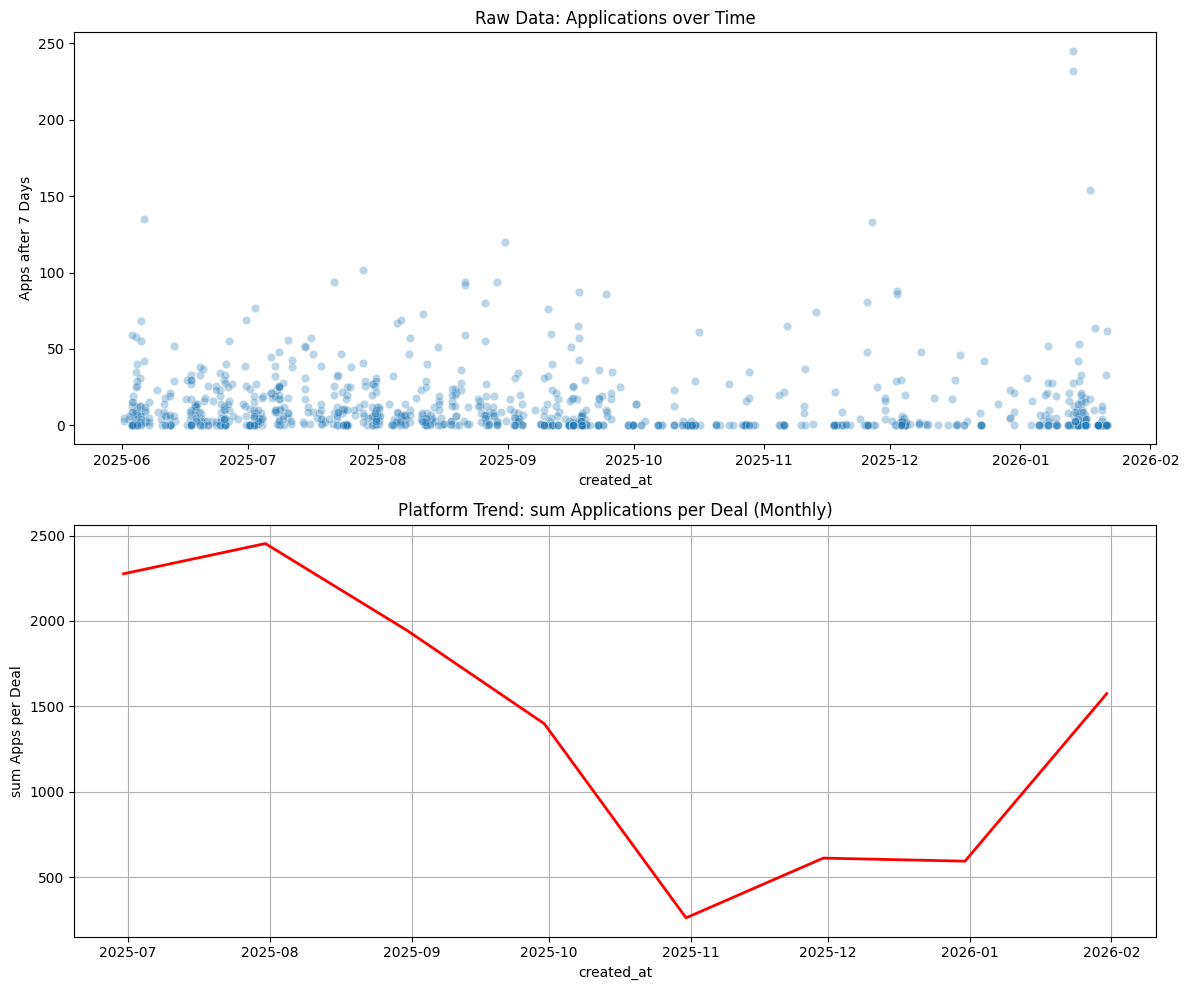

Correlation between Time and Application Count: -0.0511
Correlation between Monthly Deal Volume and sum of apps_after_7_days: 0.9471


In [125]:
visualise_var_over_time(clean_df)